<a href="https://colab.research.google.com/github/victorrp1502/grupo1_caixaverso/blob/Branch_Marcos/marcos2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pergunta 6 - Porte da empresa e salário. Empresas grandes (L), médias (M) ou pequenas (S) pagam mais? A diferença é maior em algum nível de experiência específico?

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [31]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

In [32]:
df = carregar_banco_csv('https://drive.google.com/uc?id=1k-6AbaByg4SWF9UgrJ94p4TafHHXOmUG')

In [33]:
df

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium
...,...,...,...,...,...,...,...,...,...,...,...
6594,Staff Data Analyst,Entry-level,Contract,Hybrid,2020,Canada,60000,CAD,44753,Canada,Large
6595,Staff Data Analyst,Executive-level,Full-time,On-site,2020,Nigeria,15000,USD,15000,Canada,Medium
6596,Machine Learning Manager,Senior-level,Full-time,Hybrid,2020,Canada,157000,CAD,117104,Canada,Large
6597,Data Engineer,Mid-level,Full-time,Hybrid,2020,Austria,65000,EUR,74130,Austria,Large


In [34]:
def media_salario_por_porte(df):
    return df.groupby('company_size')['salary_in_usd'].mean().round(2).reset_index().rename(columns={'company_size': 'Porte da Empresa',
              'salary_in_usd': 'Salário Médio'}).sort_values(by='Salário Médio', ascending=False)

In [35]:
media_salario_por_porte(df)

,Porte da Empresa,Salário Médio
1,Medium,149659.39
0,Large,120638.40
2,Small,87687.46


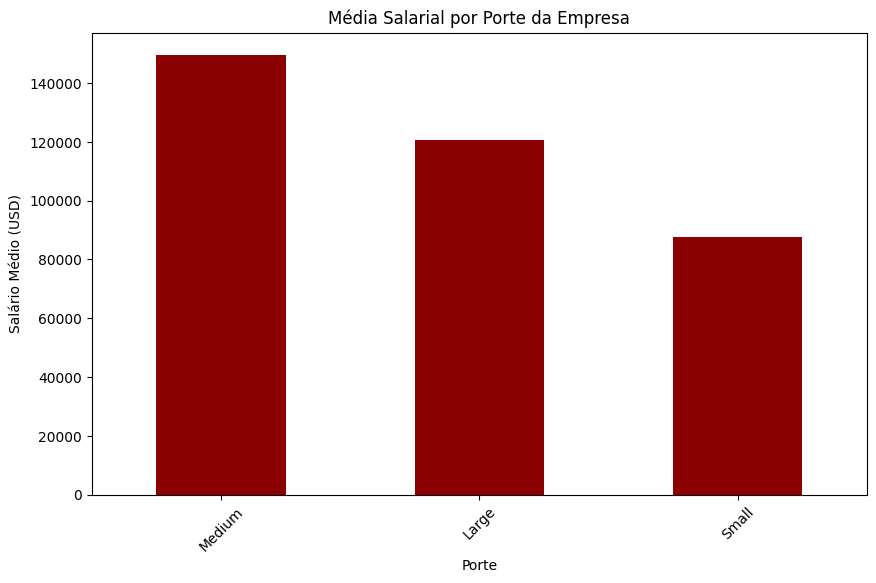

In [36]:
df_porte = media_salario_por_porte(df)

df_porte.plot(
    x='Porte da Empresa',
    y='Salário Médio',
    kind='bar',
    figsize=(10,6),
    legend=False,
    color='darkred'
)

plt.title('Média Salarial por Porte da Empresa')
plt.ylabel('Salário Médio (USD)')
plt.xlabel('Porte')
plt.xticks(rotation=45)
plt.show()

In [37]:
def media_salario_porte_por_experiencia(df):

  return df.groupby(['experience_level', 'company_size'])['salary_in_usd']\
        .mean().round(2).reset_index().rename(columns={'experience_level': 'Experiência', 'company_size': 'Porte',
        'salary_in_usd': 'Salário Médio'}).sort_values(by=['Experiência', 'Porte'], ascending=[True, True])


In [38]:
media_salario_porte_por_experiencia(df)

,Experiência,Porte,Salário Médio
0,Entry-level,Large,74603.33
1,Entry-level,Medium,89223.05
2,Entry-level,Small,68485.94
3,Executive-level,Large,187993.90
4,Executive-level,Medium,190563.40
5,Executive-level,Small,169172.38
6,Mid-level,Large,100625.17
7,Mid-level,Medium,123303.99
8,Mid-level,Small,73769.65
9,Senior-level,Large,150556.66


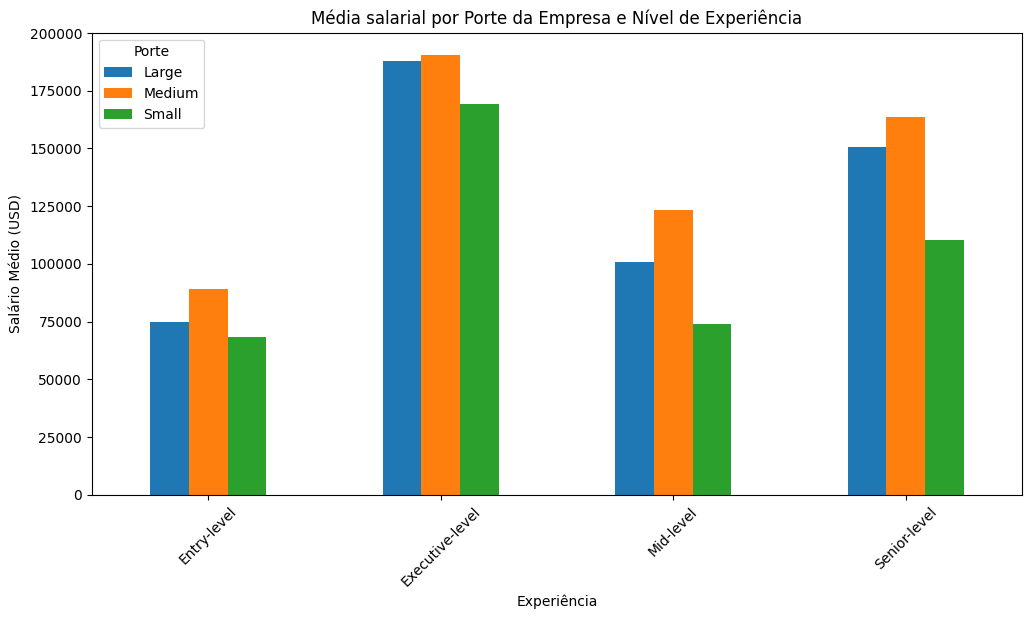

In [39]:
df_porte_experiencia = media_salario_porte_por_experiencia(df)

pivot = df_porte_experiencia.pivot(index='Experiência', columns='Porte', values='Salário Médio')

pivot.plot(kind='bar', figsize=(12,6))
plt.title('Média salarial por Porte da Empresa e Nível de Experiência')
plt.ylabel('Salário Médio (USD)')
plt.xlabel('Experiência')
plt.xticks(rotation=45)
plt.legend(title='Porte')
plt.show()

#Respondendo à pergunta:

- Segundo a análise dos dados revelou, as empresas de médio porte são as que pagam os melhores salários em média, seguidas das de grande porte. Em último lugar ficaram as de pequeno porte. As grandes empresas pagam em média 37,6% mais que a pequenas, e as de médio porte pagam em média 24% mais que as grandes - e 70,1% mais do que as pequenas empresas.

- A diferença é maior no Nível Médio, em que as empresas de médio porte apresentam remuneração 22,5% superior às de grande porte, e 67,2% superior às de pequeno porte.